# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

A possible who for my audience could be someone from the Federal reserve to get a better sense of asset concentration whether its loans, savings, etc. <br>
What I would be showing would be the concentration of assets by different type of institutions for the quarter <br>
I plan to use visual aids like a column chart to show the distribution of said data. 

# 3. Homework - work with your own data

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [6]:
df_statistics = pd.read_csv("bank_customers.csv")

In [7]:
df_statistics.columns

Index(['CustomerID', 'BirthDate', 'SSN', 'AccountID', 'AccountOpened',
       'AccountType'],
      dtype='str')

In [8]:
df_statistics.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     99 non-null     float64
 1   BirthDate      99 non-null     str    
 2   SSN            99 non-null     str    
 3   AccountID      98 non-null     float64
 4   AccountOpened  99 non-null     str    
 5   AccountType    99 non-null     str    
dtypes: float64(2), str(4)
memory usage: 4.8 KB


In [9]:
df_statistics["AccountOpened"] = pd.to_datetime(df_statistics["AccountOpened"], errors="coerce")

In [10]:
df_statistics["BirthDate"] = pd.to_datetime(df_statistics["BirthDate"], format= "%Y-%m-%d", errors="coerce")

In [11]:
df_statistics_clean = df_statistics.dropna()

In [12]:
df_statistics_clean.describe()

,CustomerID,BirthDate,AccountID,AccountOpened
count,96.000000,96,96.000000,96
mean,50.500000,1990-07-31 22:45:00,46.781250,2034-01-31 08:30:00
min,3.000000,1952-01-26 00:00:00,0.000000,1953-05-05 00:00:00
25%,26.750000,1974-12-03 18:00:00,26.500000,2011-06-02 00:00:00
50%,50.500000,1991-08-30 00:00:00,42.000000,2032-10-29 00:00:00
75%,74.250000,2005-02-28 06:00:00,71.500000,2061-09-17 00:00:00
max,98.000000,2023-12-26 00:00:00,97.000000,2095-12-10 00:00:00
std,27.856777,NaN,27.545638,NaN


I had to convert the date columns from Objects to date values <br>
I was unable to convert the SSN to integers.<br>
I removed rows that had missing values once I converted<br>
I am unsure what to do with the objects columns.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [13]:
import matplotlib.dates as mdates
import matplotlib.units as munits
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Accounts opened by Year')

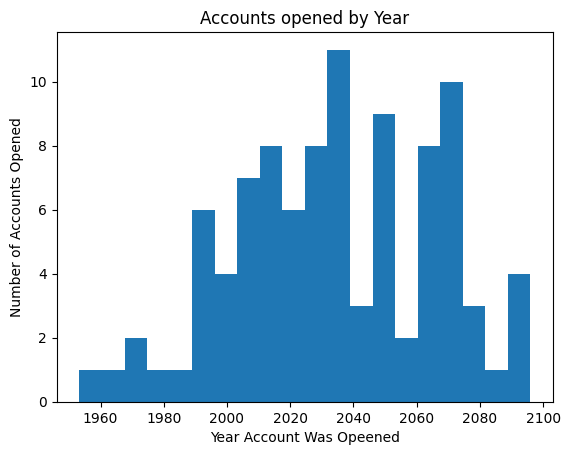

In [14]:
plt.hist(df_statistics_clean["AccountOpened"], bins=20)
plt.xlabel("Year Account Was Opeened")
plt.ylabel("Number of Accounts Opened")
plt.title("Accounts opened by Year")

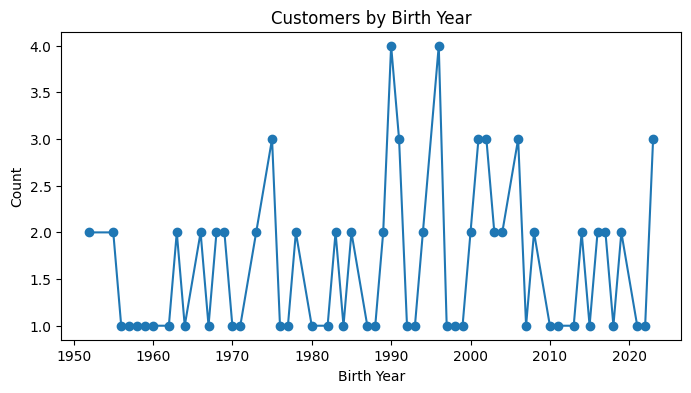

In [15]:
counts = df_statistics_clean["BirthDate"].dt.year.value_counts().sort_index()

ax = counts.plot(figsize=(8,4), marker="o", title="Customers by Birth Year")
ax.set_xlabel("Birth Year")
ax.set_ylabel("Count")
plt.show()

After plotting, it is clear this is synthetic data as their are account creations and birthdates <br>
in the future. But it was a good excercise and allowed me to reference Matplotlib documentation. 